In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import tensorflow as tf

from models.TimeSeriesTransformer import TimeSeriesTransformer
from models.LSTM import build_single_step_model

In [2]:
cols = [
    "episode",
    "step",
    "hull_angle",
    "hull_angularVelocity",
    "vel_x",
    "vel_y",
    "hip_joint_1_angle",
    "hip_joint_1_speed",
    "knee_joint_1_angle",
    "knee_joint_1_speed",
    "leg_1_ground_contact_flag",
    "hip_joint_2_angle",
    "hip_joint_2_speed",
    "knee_joint_2_angle",
    "knee_joint_2_speed",
    "leg_2_ground_contact_flag",
    "lidar_reading_1",
    "lidar_reading_2",
    "lidar_reading_3",
    "lidar_reading_4",
    "lidar_reading_5",
    "lidar_reading_6",
    "lidar_reading_7",
    "lidar_reading_8",
    "lidar_reading_9",
    "lidar_reading_10",
    "action_0",
    "action_1",
    "action_2",
    "action_3"
]


In [3]:
env = gym.make(
    "BipedalWalker-v3", 
    # render_mode="human", 
    hardcore=False
)

In [4]:
def sample_episodes(max_steps = 300, num_episodes = 1000):
    train_dataset = []
    for i in tqdm(range(num_episodes)):
        env.reset()
        terminated = False

        step = 0
        while not terminated:
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)
            train_dataset.append((i, step, *obs, *action))
            step += 1
            terminated = terminated or step > max_steps

    df = pd.DataFrame(train_dataset)

    df.columns = cols

    return df


In [5]:
# create train dataset
df = sample_episodes(max_steps = 300, num_episodes = 1000)

100%|██████████| 1000/1000 [00:35<00:00, 27.82it/s]


In [6]:
#############################################
#### HELPER FUNCTIONS FOR PATTERN GENERATION
#############################################
def create_training_data(data, input_col, target_col, window_size=1, training_pattern_percent=0.7):

    data_train = data

    mean_in, std_in = mean_and_std(input_col, data_train)
    mean_out, std_out = mean_and_std(target_col, data_train)

    grouped = data_train.groupby(['episode'])

    inputs_all = []
    labels_all = []

    for g in grouped:
        # be sure that data inside a group is not shuffled # not sure if needed
        g = g[1].sort_values(by='step')

        past_history = window_size   # t-3, t-2, t-1, t
        future_target = 0  # t+1
        STEP = 1 # no subsampling of rows in data, e.g. only every i'th row

        # use pandas.DataFrame.values in order to get an numpy array from an pandas.DataFrame object

        inputs, labels = multivariate_data(dataset=g[input_col][:].values, target=g[target_col][:].values,
                                        start_index=0, end_index=g[input_col][:].values.shape[0]-future_target,
                                        history_size=past_history, target_size=future_target, step=STEP,
                                        single_step=True)

        ## Append data to whole set of patterns
        for i in range (0, len(inputs)):
            inputs_all.append(inputs[i])
            labels_all.append(labels[i])
  
    length = len(inputs_all)

    c = list(zip(inputs_all, labels_all))
    np.random.shuffle(c)
    inputs_all, labels_all = zip(*c)

    split = int(training_pattern_percent * length)

    inputs_all = np.array(inputs_all)
    labels_all = np.array(labels_all)

    return ((inputs_all[0:split], labels_all[0:split]), (inputs_all[split:], labels_all[split:])), mean_in, std_in, mean_out, std_out


def mean_and_std(columns, data):
    mean = np.zeros(len(columns))
    std = np.zeros(len(columns))
    index = 0
    for c in columns:
        mean[index], std[index] = get_normalizations(data[c])
        index = index + 1
    return mean, std

def get_normalizations(data):
    mean = data.mean()
    std = data.std()
    return mean, std

def multivariate_data(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
    data = []
    labels = []

    start_index = start_index + history_size
    if end_index is None:
       end_index = len(dataset) - target_size

    for i in range(start_index, end_index):
        indices = range(i-history_size, i, step)
        data.append(dataset[indices])

        if single_step:
            labels.append(target[i+target_size])
        else:
            labels.append(target[i:i+target_size])

    return np.array(data, dtype=np.float32), np.array(labels, dtype=np.float32)



def prepare_data(df, input_col, target_col, window_size, training_batch_size=50, validation_batch_size=50, training_pattern_percent=0.7):
    
    global x_train_multi, y_train_multi
    
    ###################
    ## PREPARE DATASET
    ###################
    ((x_train_multi, y_train_multi), (x_val_multi, y_val_multi)), mean_in, std_in, mean_out, std_out = \
                                    create_training_data(df, input_col, target_col, window_size=window_size,
                                                        training_pattern_percent=training_pattern_percent)

    train_data = tf.data.Dataset.from_tensor_slices((x_train_multi, y_train_multi))
    #train_data = train_data.cache().shuffle(max_training_pattern).batch(training_batch_size).repeat()
    train_data = train_data.shuffle(x_train_multi.shape[0]).batch(training_batch_size).repeat()

    val_data = tf.data.Dataset.from_tensor_slices((x_val_multi, y_val_multi))
    val_data = val_data.batch(validation_batch_size).repeat()
    input_shape = x_train_multi[0].shape[-2:]
    return train_data, val_data, input_shape, mean_in, std_in, mean_out, std_out


In [7]:
input_col = cols[2:]
target_col = cols[2:-4]

In [8]:
window_size=4

train_data, val_data, input_shape, mean_in, std_in, mean_out, std_out =  \
            prepare_data(df, input_col, target_col, window_size=window_size, training_pattern_percent=0.7)

print ("Input-Shape: ", input_shape)

Input-Shape:  (4, 28)


# Train LSTM

In [9]:
modelpath="model.h5"
max_epochs=1000
steps_per_epoch = 100
validation_steps = 100
validation_freq = 1

es_callback = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=50, restore_best_weights=True, verbose=True)
mc_trainLoss_callback = tf.keras.callbacks.ModelCheckpoint(filepath="%s.bestTrainLoss" % modelpath, monitor='loss', verbose=1, save_best_only=True, mode=min)
mc_valLoss_callback = tf.keras.callbacks.ModelCheckpoint(filepath="%s.bestValLoss" % modelpath, monitor='val_loss', verbose=1, save_best_only=True, mode=min)
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir = ".\model_logs_tb", histogram_freq=1)

In [10]:
model = build_single_step_model(mean_in, std_in, mean_out, std_out, input_shape)
history = model.fit(train_data, epochs=max_epochs, steps_per_epoch=steps_per_epoch,
                        validation_data=val_data, validation_steps=validation_steps, validation_freq=validation_freq,
                        callbacks=[mc_trainLoss_callback, mc_valLoss_callback, es_callback, tensorboard_callback],
                        verbose=1)
model.save(modelpath)


INFO:tensorflow:Assets written to: model.h5.bestTrainLoss\assets
INFO:tensorflow:Assets written to: model.h5.bestValLoss\assets
INFO:tensorflow:Assets written to: model.h5.bestTrainLoss\assets
INFO:tensorflow:Assets written to: model.h5.bestValLoss\assets
INFO:tensorflow:Assets written to: model.h5.bestTrainLoss\assets
INFO:tensorflow:Assets written to: model.h5.bestValLoss\assets
INFO:tensorflow:Assets written to: model.h5.bestTrainLoss\assets
INFO:tensorflow:Assets written to: model.h5.bestValLoss\assets
INFO:tensorflow:Assets written to: model.h5.bestTrainLoss\assets
INFO:tensorflow:Assets written to: model.h5.bestValLoss\assets
INFO:tensorflow:Assets written to: model.h5.bestTrainLoss\assets
INFO:tensorflow:Assets written to: model.h5.bestValLoss\assets
INFO:tensorflow:Assets written to: model.h5.bestValLoss\assets
INFO:tensorflow:Assets written to: model.h5.bestTrainLoss\assets
INFO:tensorflow:Assets written to: model.h5.bestValLoss\assets
INFO:tensorflow:Assets written to: model.

KeyboardInterrupt: 

# Train Transformer

In [11]:
# Define model parameters
modelpath = "transformer_model"
max_epochs = 1000
steps_per_epoch = 100
validation_steps = 100
validation_freq = 1


num_layers = 2
d_model = 128
num_heads = 8
dff = 512

# Define callbacks
es_callback = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=50, restore_best_weights=True, verbose=1)
#mc_trainLoss_callback = tf.keras.callbacks.ModelCheckpoint(filepath=f"{modelpath}.bestTrainLoss", monitor='loss', verbose=1, save_best_only=True, mode='min')
mc_valLoss_callback = tf.keras.callbacks.ModelCheckpoint(filepath=f"{modelpath}/model.bestValLoss", monitor='val_loss', verbose=1, save_best_only=True, mode='min')
#tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=r"./model_logs_tb", histogram_freq=1)

# Ensure your model is defined
model = TimeSeriesTransformer(num_layers=2, d_model=64, num_heads=4, dff=128, 
                              input_shape=input_shape, output_dim=len(mean_out), rate=0.001)
model.compile(optimizer="adam", loss="mse")

history = model.fit(train_data, epochs=max_epochs, steps_per_epoch=steps_per_epoch,
                        validation_data=val_data, validation_steps=validation_steps, validation_freq=validation_freq,
                        callbacks=[mc_valLoss_callback ,es_callback])

# Save the model
model.save(modelpath, save_format='tf')

INFO:tensorflow:Assets written to: transformer_model\model.bestValLoss\assets
INFO:tensorflow:Assets written to: transformer_model\model.bestValLoss\assets
INFO:tensorflow:Assets written to: transformer_model\model.bestValLoss\assets
INFO:tensorflow:Assets written to: transformer_model\model.bestValLoss\assets
INFO:tensorflow:Assets written to: transformer_model\model.bestValLoss\assets
INFO:tensorflow:Assets written to: transformer_model\model.bestValLoss\assets
INFO:tensorflow:Assets written to: transformer_model\model.bestValLoss\assets
INFO:tensorflow:Assets written to: transformer_model\model.bestValLoss\assets
INFO:tensorflow:Assets written to: transformer_model\model.bestValLoss\assets
INFO:tensorflow:Assets written to: transformer_model\model.bestValLoss\assets
INFO:tensorflow:Assets written to: transformer_model\model.bestValLoss\assets
INFO:tensorflow:Assets written to: transformer_model\model.bestValLoss\assets
INFO:tensorflow:Assets written to: transformer_model\model.bestV

In [14]:
import collections
import numpy as np
import pandas as pd
import tensorflow as tf

def run_model_evaluation(model, dfEval, input_col, target_col, cols, window_size, output_min, output_max):
    """
    This function performs model evaluation with a state buffer and returns a DataFrame with the model predictions.

    Parameters:
    - model: Trained Keras model for prediction.
    - dfEval: DataFrame containing the input data for evaluation.
    - input_col: List of columns used as input to the model.
    - target_col: List of target columns that model predicts.
    - cols: Additional columns used in state buffer updates.
    - window_size: Size of the sliding window for the input state.
    - output_min: Minimum value to clip model predictions.
    - output_max: Maximum value to clip model predictions.

    Returns:
    - dfNet: DataFrame containing the predicted transitions.
    """
    
    # FIFO-buffer that keeps the neural state
    stateBuffer = collections.deque(maxlen=window_size)
    
    # List to store the outputs of neural network
    transitions = []

    # Iterate through each row in dfEval
    for i in range(len(dfEval)):
        # Estimation of first state
        if i < window_size:
            state_data = np.float32([dfEval[col].values[i] for col in input_col])
            stateBuffer.append(state_data)
        else:
            # Prepare the state from the state buffer
            state = np.array([list(stateBuffer)])

            # Recall neural network to predict successor state
            netOutput = model.predict(np.float32(state))[0]

            # Clip output to the observed data bounds
            netOutput = np.clip(netOutput, output_min, output_max)

            # Append the prediction to transitions
            transitions.append({col: netOutput[index] for index, col in enumerate(target_col)})

            # Update RNN state buffer with predicted and additional values
            stateBuffer.append(np.float32([
                *[netOutput[index] for index in range(len(target_col))],
                dfEval[cols[-4]].values[i],
                dfEval[cols[-3]].values[i],
                dfEval[cols[-2]].values[i],
                dfEval[cols[-1]].values[i]
            ]))

    # Convert the list of transitions to a DataFrame
    dfNet = pd.DataFrame(transitions)

    return dfNet


In [12]:
dfEval = sample_episodes(num_episodes=100, max_steps=500)
dfEval.describe()

row_max_steps = dfEval[dfEval.step == dfEval.step.max()]
dfEval = dfEval[~dfEval.episode.isin(row_max_steps.episode.unique())]
row_max_steps = dfEval[dfEval.step == dfEval.step.max()]
dfEval = dfEval[dfEval.episode==int(row_max_steps.episode)]

100%|██████████| 100/100 [00:05<00:00, 17.88it/s]
C:\Users\Flo\AppData\Local\Temp\ipykernel_19952\481348435.py:7: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  dfEval = dfEval[dfEval.episode==int(row_max_steps.episode)]


In [15]:
dfEval

,episode,step,hull_angle,hull_angularVelocity,vel_x,vel_y,hip_joint_1_angle,hip_joint_1_speed,knee_joint_1_angle,knee_joint_1_speed,...,lidar_reading_5,lidar_reading_6,lidar_reading_7,lidar_reading_8,lidar_reading_9,lidar_reading_10,action_0,action_1,action_2,action_3
12238,54,0,-0.017242,-0.023238,-0.013883,-0.002173,0.453106,0.261175,0.115159,-0.114040,...,0.544130,0.613772,0.722463,0.902565,1.000000,1.000000,0.850282,0.462562,-0.210851,-0.356479
12239,54,1,-0.030124,-0.025802,-0.016407,-0.031352,0.531284,1.000000,-0.000924,-1.000000,...,0.542279,0.611683,0.720004,0.899494,1.000000,1.000000,0.778089,-0.675983,-0.594309,-0.698899
12240,54,2,-0.043867,-0.027596,-0.016933,-0.049573,0.609885,1.000000,-0.116321,-1.000000,...,0.539376,0.608409,0.716151,0.894679,1.000000,1.000000,0.406931,-0.540875,0.083331,-0.879964
12241,54,3,-0.047092,-0.006624,-0.000208,-0.051476,0.632083,0.302995,-0.025359,0.724410,...,0.536416,0.605070,0.712220,0.889768,1.000000,1.000000,0.248146,0.423225,-0.774636,-0.270744
12242,54,4,-0.056239,-0.018449,-0.006641,-0.068613,0.656504,0.351147,0.100633,1.000000,...,0.532460,0.600608,0.706968,0.883207,1.000000,1.000000,0.153433,0.961482,0.168095,-0.935914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12411,54,173,1.957383,0.086252,-0.227297,-0.171882,-0.468970,-0.027244,-0.630205,0.262989,...,0.271267,0.305985,0.360171,0.449958,0.617859,1.000000,0.683883,0.882831,0.195306,0.562100
12412,54,174,2.018473,0.122188,-0.242078,-0.153813,-0.504448,-0.447473,-0.616757,0.109070,...,0.262357,0.295935,0.348341,0.435179,0.597566,0.988703,-0.347789,0.871194,-0.388049,0.057726
12413,54,175,2.061234,0.085587,-0.234383,-0.189696,-0.494668,0.202279,-0.488624,1.000000,...,0.251462,0.283646,0.333876,0.417108,0.572751,0.947646,0.778991,0.486329,0.145082,-0.816925
12414,54,176,2.084196,0.046124,-0.234799,-0.228376,-0.415036,1.000000,-0.530971,-0.418134,...,0.238437,0.268954,0.316583,0.395503,0.543085,0.898561,0.858986,-0.393222,0.840515,0.488980


In [14]:
output_min = y_train_multi.min(axis=0)
output_max = y_train_multi.max(axis=0)
print ("min(output)_data: ", output_min)
print ("max(output)_data: ", output_max)

min(output)_data:  [-2.1125288  -0.21256113 -0.38409725 -0.4344518  -0.93725187 -2.159245
 -0.8719846  -3.1915805   0.         -0.9501973  -2.0771024  -0.8534063
 -2.9408138   0.          0.06100076  0.06169352  0.06385265  0.06774498
  0.07391025  0.08336981  0.0981335   0.12259709  0.16834402  0.2785338 ]
max(output)_data:  [3.207949   0.23085736 0.41377842 0.16515736 1.2156415  1.9108931
 1.2335894  3.3744485  1.         1.2305545  1.9812446  1.2224083
 3.0883992  1.         0.49313372 0.498734   0.5161885  0.54765433
 0.59749484 0.6739664  0.79331696 0.9910821  1.         1.        ]


In [35]:
import collections

# load model
lstm_model = tf.keras.models.load_model("model.h5.bestValLoss", compile=False)

# load transformer model
transformer_model = tf.keras.models.load_model("transformer_model/model.bestValLoss", compile=False)

lstm_dfNet = run_model_evaluation(
    model=lstm_model,
    dfEval=dfEval,
    input_col=input_col,
    target_col=target_col,
    cols=cols,
    window_size=window_size,
    output_min=output_min,
    output_max=output_max
)

dfNet = run_model_evaluation(
    model=transformer_model,
    dfEval=dfEval,
    input_col=input_col,
    target_col=target_col,
    cols=cols,
    window_size=window_size,
    output_min=output_min,
    output_max=output_max
)


1/1 [==============================] - 0s 210ms/step
[[[-0.05495586 -0.06841567 -0.03918022 -0.02018508  0.54443496
    0.93170094  0.11950016 -0.32691902  1.          0.4212504
    0.583781    0.10569513 -0.4254181   1.          0.445209
    0.45026502  0.46602324  0.49443108  0.5394279   0.60846764
    0.7162192   0.89476466  1.          1.          0.8771026
    0.7725919   0.24144699  0.6575783 ]
  [-0.07981122 -0.0496725  -0.03268434 -0.05179017  0.6512336
    1.1521944   0.01666927 -0.99999976  1.          0.5156694
    1.          0.00805789 -0.9999998   0.          0.44259036
    0.44761664  0.46328217  0.4915229   0.53625506  0.60488874
    0.7120065   0.88950187  1.          1.         -0.47187233
   -0.94614166  0.9472688  -0.5151749 ]
  [-0.08346154 -0.00734746 -0.00243569 -0.04893391  0.6800263
    0.3912331  -0.09961057 -0.9999998   0.          0.4844607
   -0.37696484  0.08713484  0.22628993  1.          0.44027427
    0.44527423  0.4608578   0.48895076  0.5334488   0.60

In [36]:
dfNet

,hull_angle,hull_angularVelocity,vel_x,vel_y,hip_joint_1_angle,hip_joint_1_speed,knee_joint_1_angle,knee_joint_1_speed,leg_1_ground_contact_flag,hip_joint_2_angle,...,lidar_reading_1,lidar_reading_2,lidar_reading_3,lidar_reading_4,lidar_reading_5,lidar_reading_6,lidar_reading_7,lidar_reading_8,lidar_reading_9,lidar_reading_10
0,-0.106416,-0.003937,0.001853,-0.062373,0.726155,0.129800,-0.175134,-0.352103,0.139004,0.503361,...,0.440993,0.446002,0.461611,0.489750,0.534322,0.602709,0.709443,0.886307,1.000000,0.987883
1,-0.126706,-0.019471,0.001464,-0.064450,0.764004,0.146542,-0.256972,-0.249067,0.152059,0.526064,...,0.443483,0.448520,0.464217,0.492515,0.537338,0.606111,0.713448,0.891313,1.000000,1.000000
2,-0.148728,-0.010381,0.010379,-0.059403,0.791554,0.064601,-0.304861,-0.120598,0.182151,0.525304,...,0.438517,0.443497,0.459018,0.487000,0.531320,0.599323,0.705457,0.881325,1.000000,1.000000
3,-0.159039,-0.022234,0.012373,-0.066552,0.823975,0.159022,-0.370585,-0.243746,0.184266,0.518675,...,0.434734,0.439671,0.455059,0.482799,0.526738,0.594155,0.699375,0.873729,1.000000,1.000000
4,-0.189834,-0.019062,0.023109,-0.066091,0.861174,0.103261,-0.432246,-0.192037,0.143119,0.500794,...,0.430049,0.434933,0.450155,0.477596,0.521061,0.587752,0.691838,0.864312,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,-1.705018,-0.118537,0.050243,-0.147804,0.901652,0.265002,-0.333375,-0.035977,0.204731,0.881305,...,0.171129,0.173073,0.179130,0.190049,0.207344,0.233879,0.275293,0.343917,0.523033,0.963094
143,-1.718437,-0.114903,0.059471,-0.153762,0.917885,0.293168,-0.311909,-0.181019,0.133611,0.887723,...,0.176381,0.178384,0.184627,0.195881,0.213707,0.241057,0.283742,0.354474,0.546705,0.970190
144,-1.712710,-0.118692,0.053562,-0.146803,0.912478,0.262767,-0.306159,-0.154335,0.061654,0.890841,...,0.174375,0.176355,0.182526,0.193652,0.211275,0.238314,0.280512,0.350437,0.527598,0.966180
145,-1.717558,-0.117525,0.042561,-0.143279,0.911842,0.289762,-0.299080,-0.197739,0.020775,0.892955,...,0.172662,0.174622,0.180734,0.191750,0.209199,0.235972,0.277754,0.346991,0.517685,0.964096


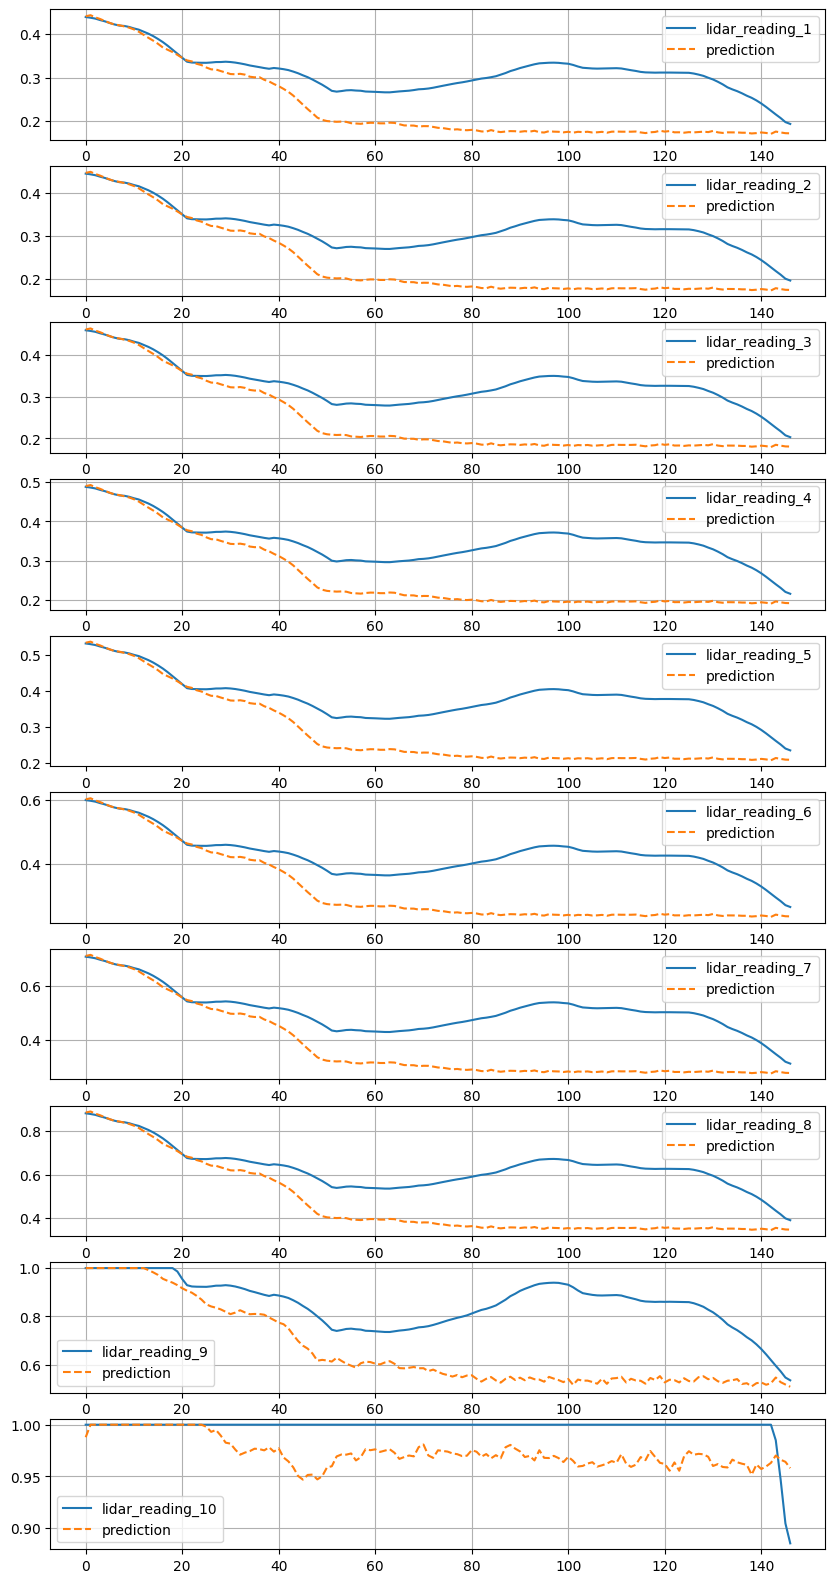

In [38]:
fields = [c for c in target_col if "lidar" in c]
fig, axs = plt.subplots (len(fields), 1, figsize=(10,20))


for i in range (len(fields)):
    f = fields[i]
    axs[i].plot(range (len(dfNet)), dfEval[f].values[window_size:window_size+len(dfNet)], label=f)
    axs[i].plot(range (len(dfNet)), dfNet[f].values, label="prediction", ls="--")
    axs[i].grid()
    axs[i].legend(loc="best")
    
# axs[4].plot(range (len(dfNet)), dfEval[ACTION].values[window_size:window_size+len(dfNet)], label=ACTION)
axs[4].grid()
axs[4].legend(loc="best")
